# TCGA Pan-Cancer EDA for Predicting TP53 Mutation Status from RNA Expression

## Objective
Use TCGA RNA expression data to explore whether TP53 mutation status can be predicted from transcriptomic profiles.

## Data sources
- RNA: `tcga_RSEM_gene_tpm.gz`
- Somatic mutations: `mc3.v0.2.8.PUBLIC.xena.gz`
- Clinical / phenotype: `Survival_SupplementalTable_S1_20171025_xena_sp`

## Main EDA goals
1. Define a clean TP53 mutation label
2. Build a sample-level merged dataset
3. Quantify class balance and cohort composition
4. Check cancer-type confounding
5. Inspect RNA quality and structure
6. Identify issues that should shape the modeling notebook

## Key warning
In TCGA, cancer type can strongly confound TP53 prediction because cancer type affects both mutation prevalence and gene expression.

In [1]:
import gzip
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
sns.set_context("notebook")

In [2]:
# TODO: update these paths
DATA_DIR = Path("./data")

RNA_PATH = DATA_DIR / "tcga_RSEM_gene_tpm.gz"
MUT_PATH = DATA_DIR / "mc3.v0.2.8.PUBLIC.xena.gz"
PHENO_PATH = DATA_DIR / "Survival_SupplementalTable_S1_20171025_xena_sp"
TP53_TARGETS_PATH = DATA_DIR / "tp53_target_genes_fischer2017.csv"  # optional, mostly for later modeling

RANDOM_STATE = 42
TOP_VAR_GENES_FOR_PCA = 2000

## Load raw TCGA files

First load the RNA, mutation, and phenotype tables and inspect their shape, columns, and identifier formats before making any assumptions.

In [3]:
rna_raw = pd.read_csv(RNA_PATH, sep="\t")
mut_raw = pd.read_csv(MUT_PATH, sep="\t")
pheno_raw = pd.read_csv(PHENO_PATH, sep="\t")

print("RNA shape:", rna_raw.shape)
print("Mutation shape:", mut_raw.shape)
print("Phenotype shape:", pheno_raw.shape)

display(rna_raw.head())
display(mut_raw.head())
display(pheno_raw.head())

RNA shape: (60498, 10536)
Mutation shape: (2907335, 12)
Phenotype shape: (12591, 34)


,sample,TCGA-19-1787-01,TCGA-S9-A7J2-01,TCGA-G3-A3CH-11,TCGA-EK-A2RE-01,TCGA-44-6778-01,TCGA-F4-6854-01,TCGA-AB-2863-03,TCGA-C8-A1HL-01,TCGA-EW-A2FS-01,TCGA-IR-A3L7-01,TCGA-05-4420-01,TCGA-R6-A8WC-01,TCGA-DX-A3U8-01,TCGA-GL-8500-01,TCGA-E2-A153-11,TCGA-BR-A4J6-01,TCGA-EJ-7125-01,TCGA-IN-7808-01,TCGA-L5-A4OH-01,TCGA-RP-A695-06,TCGA-AX-A3G6-01,TCGA-B9-A8YH-01,TCGA-E1-A7YI-01,TCGA-PC-A5DM-01,TCGA-BR-A4QL-01,TCGA-CH-5751-01,TCGA-A2-A3XX-01,TCGA-DQ-5624-01,TCGA-KK-A7B3-01,TCGA-DQ-7591-01,TCGA-06-5412-01,TCGA-BP-4989-01,TCGA-EJ-8468-01,TCGA-CZ-5459-01,TCGA-D5-5538-01,TCGA-56-8305-01,TCGA-CZ-5468-11,TCGA-BH-A0BQ-11,TCGA-4X-A9FA-01,TCGA-DD-AAW0-01,TCGA-AA-3511-01,TCGA-Z7-A8R5-01,TCGA-CZ-4863-11,TCGA-39-5031-01,TCGA-ZG-A8QW-01,TCGA-DU-7302-01,TCGA-DJ-A3UX-01,TCGA-ZN-A9VQ-01,TCGA-EI-6512-01,TCGA-J4-A83K-01,TCGA-EE-A17X-06,TCGA-HZ-7922-01,TCGA-DD-AACA-02,TCGA-DD-AACA-01,TCGA-D3-A8GD-06,TCGA-13-1485-01,TCGA-QG-A5YX-01,TCGA-ZG-A9MC-01,TCGA-DU-A7TI-01,TCGA-A3-3335-01,TCGA-BR-8372-01,TCGA-HC-7742-01,TCGA-DD-A3A6-11,TCGA-64-1679-01,TCGA-CV-5976-01,TCGA-25-1315-01,TCGA-2G-AAFZ-01,TCGA-LN-A4MQ-01,TCGA-CV-6948-01,TCGA-K7-AAU7-01,TCGA-CJ-6028-01,TCGA-B6-A0RL-01,TCGA-CZ-5456-01,TCGA-EL-A3D0-01,TCGA-EM-A22Q-01,TCGA-49-6744-01,TCGA-L5-A4ON-01,TCGA-FS-A1ZF-06,TCGA-ZN-A9VU-01,TCGA-Q3-A5QY-01,TCGA-AJ-A3BI-01,TCGA-W2-A7UY-01,TCGA-BH-A204-11,TCGA-E3-A3E2-01,TCGA-FB-A545-01,TCGA-44-2657-11,TCGA-G4-6320-01,TCGA-EB-A41A-01,TCGA-55-6982-01,TCGA-RC-A7SH-01,TCGA-CC-A3MA-01,TCGA-DD-A3A5-11,TCGA-RC-A7SB-01,TCGA-CM-6164-01,TCGA-ET-A3BW-01,TCGA-09-0369-01,TCGA-E2-A2P6-01,TCGA-VD-A8KF-01,TCGA-EL-A4JZ-01,...,TCGA-AB-2833-03,TCGA-EE-A2MF-06,TCGA-D8-A1XR-01,TCGA-50-5072-01,TCGA-AB-2964-03,TCGA-HI-7171-01,TCGA-AR-A0TQ-01,TCGA-G3-A3CG-01,TCGA-BB-7863-01,TCGA-DU-6406-01,TCGA-BR-4255-01,TCGA-AA-3675-01,TCGA-JV-A75J-01,TCGA-DD-A1ED-01,TCGA-BH-A18P-01,TCGA-VD-A8KJ-01,TCGA-A6-6782-01,TCGA-BR-A4CR-01,TCGA-2Y-A9H8-01,TCGA-61-1721-01,TCGA-56-8628-01,TCGA-2Y-A9GT-01,TCGA-EO-A3AZ-01,TCGA-3N-A9WD-06,TCGA-29-1784-01,TCGA-2L-AAQI-01,TCGA-HS-A5N9-01,TCGA-VS-A9UT-01,TCGA-E2-A15O-01,TCGA-50-5045-01,TCGA-DA-A95W-06,TCGA-BP-4332-01,TCGA-AO-A12C-01,TCGA-86-8674-01,TCGA-CZ-5451-11,TCGA-FF-8043-01,TCGA-P3-A5Q5-01,TCGA-N8-A4PQ-01,TCGA-50-8457-01,TCGA-ZJ-AAX8-01,TCGA-OL-A97C-01,TCGA-18-3416-01,TCGA-B8-4146-01,TCGA-AB-2937-03,TCGA-56-7222-11,TCGA-68-7755-01,TCGA-EE-A2GN-06,TCGA-V1-A9ZR-01,TCGA-2J-AABK-01,TCGA-EJ-A6RC-01,TCGA-EL-A3GP-01,TCGA-D9-A4Z6-06,TCGA-E2-A15K-11,TCGA-06-0743-01,TCGA-H2-A3RI-01,TCGA-21-5787-01,TCGA-BJ-A18Z-01,TCGA-D7-A6EX-01,TCGA-TM-A84B-01,TCGA-OR-A5K0-01,TCGA-FY-A4B4-01,TCGA-BH-A18G-01,TCGA-13-0725-01,TCGA-B6-A0IA-01,TCGA-A8-A090-01,TCGA-BB-4217-01,TCGA-5T-A9QA-01,TCGA-TN-A7HJ-01,TCGA-AN-A0XT-01,TCGA-TS-A8AS-01,TCGA-J4-8198-01,TCGA-DU-A76O-01,TCGA-EE-A29L-06,TCGA-4X-A9F9-01,TCGA-C5-A1BJ-01,TCGA-G2-AA3C-01,TCGA-HU-8602-01,TCGA-CR-6470-01,TCGA-CH-5768-01,TCGA-2H-A9GM-01,TCGA-XH-A853-01,TCGA-CM-4751-01,TCGA-AO-A0J4-01,TCGA-55-6985-11,TCGA-YL-A9WK-01,TCGA-77-6844-01,TCGA-IN-AB1X-11,TCGA-A2-A0YK-01,TCGA-18-3414-01,TCGA-13-1481-01,TCGA-DJ-A2QC-01,TCGA-A8-A09K-01,TCGA-61-1907-01,TCGA-IB-7885-01,TCGA-95-7947-01,TCGA-VQ-AA6F-01,TCGA-BR-8588-01,TCGA-24-2254-01,TCGA-DD-A115-01,TCGA-FV-A3I0-11
0,ENSG00000242268.2,-9.9658,0.2998,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-0.6873,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-0.8599,-0.4521,-9.9658,-9.9658,-9.9658,-4.6082,-9.9658,-9.9658,-9.9658,-4.2934,-3.6259,-9.9658,-4.6082,-9.9658,-9.9658,-9.9658,-9.9658,-4.6082,-9.9658,-4.6082,-9.9658,-9.9658,-9.9658,-9.9658,-2.5479,-1.2481,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.965800,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-0.6193,-1.3921,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-2.0529,-9.9658,-9.9658,-3.1714,-3.3076,-9.9658,-5.0116,1.0711,-2.1140,-9.9658,-9.9658,-9.9658,-9.9658,-4.6082,-9.9658,-9.9658,-0.9686,0.1257,-3.4580,-4.2934,-9.9658,-9.9658,-9.9658,-4.6082,-9.9658,-9.9658,-9.9658,-9.9658,-0.4131,-9.9658,-9.9658,-9.9658,-

,sample,chr,start,end,reference,alt,gene,effect,Amino_Acid_Change,DNA_VAF,SIFT,PolyPhen
0,TCGA-02-0003-01,10,123810032,123810032,C,T,TACC2,Missense_Mutation,p.T38M,0.88,NaN,benign(0.335)
1,TCGA-02-0003-01,10,133967449,133967449,C,T,JAKMIP3,Silent,p.D723D,0.79,NaN,NaN
2,TCGA-02-0003-01,11,124489539,124489539,G,A,PANX3,Missense_Mutation,p.R296Q,0.41,tolerated(0.37),benign(0.001)
3,TCGA-02-0003-01,11,47380512,47380512,G,T,SPI1,Missense_Mutation,p.P127T,0.50,tolerated(0.08),benign(0.093)
4,TCGA-02-0003-01,11,89868837,89868837,C,T,NAALAD2,Missense_Mutation,p.R65C,0.51,deleterious(0.01),benign(0.034)


,sample,_PATIENT,cancer type abbreviation,age_at_initial_pathologic_diagnosis,gender,race,ajcc_pathologic_tumor_stage,clinical_stage,histological_type,histological_grade,initial_pathologic_dx_year,menopause_status,birth_days_to,vital_status,tumor_status,last_contact_days_to,death_days_to,cause_of_death,new_tumor_event_type,new_tumor_event_site,new_tumor_event_site_other,new_tumor_event_dx_days_to,treatment_outcome_first_course,margin_status,residual_tumor,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,Redaction
0,TCGA-OR-A5J1-01,TCGA-OR-A5J1,ACC,58.0,MALE,WHITE,Stage II,NaN,Adrenocortical carcinoma- Usual Type,NaN,2000.0,NaN,-21496.0,Dead,WITH TUMOR,NaN,1355.0,NaN,Distant Metastasis,Peritoneal Surfaces,NaN,754.0,Complete Remission/Response,NaN,NaN,1.0,1355.0,1.0,1355.0,1.0,754.0,1.0,754.0,NaN
1,TCGA-OR-A5J2-01,TCGA-OR-A5J2,ACC,44.0,FEMALE,WHITE,Stage IV,NaN,Adrenocortical carcinoma- Usual Type,NaN,2004.0,NaN,-16090.0,Dead,WITH TUMOR,NaN,1677.0,NaN,Distant Metastasis,Soft Tissue,NaN,289.0,Progressive Disease,NaN,NaN,1.0,1677.0,1.0,1677.0,NaN,NaN,1.0,289.0,NaN
2,TCGA-OR-A5J3-01,TCGA-OR-A5J3,ACC,23.0,FEMALE,WHITE,Stage III,NaN,Adrenocortical carcinoma- Usual Type,NaN,2008.0,NaN,-8624.0,Alive,WITH TUMOR,2091.0,NaN,NaN,Distant Metastasis,Lung,NaN,53.0,Complete Remission/Response,NaN,NaN,0.0,2091.0,0.0,2091.0,1.0,53.0,1.0,53.0,NaN
3,TCGA-OR-A5J4-01,TCGA-OR-A5J4,ACC,23.0,FEMALE,WHITE,Stage IV,NaN,Adrenocortical carcinoma- Usual Type,NaN,2000.0,NaN,-8451.0,Dead,WITH TUMOR,NaN,423.0,NaN,Locoregional Recurrence,Peritoneal Surfaces,NaN,126.0,Progressive Disease,NaN,NaN,1.0,423.0,1.0,423.0,NaN,NaN,1.0,126.0,NaN
4,TCGA-OR-A5J5-01,TCGA-OR-A5J5,ACC,30.0,MALE,WHITE,Stage III,NaN,Adrenocortical carcinoma- Usual Type,NaN,2000.0,NaN,-11171.0,Dead,WITH TUMOR,NaN,365.0,NaN,Locoregional Recurrence,"Other, specify",vena cava thrombus,50.0,Progressive Disease,NaN,NaN,1.0,365.0,1.0,365.0,NaN,NaN,1.0,50.0,NaN


In [4]:
print("RNA columns (first 20):", list(rna_raw.columns[:20]))
print("Mutation columns:", list(mut_raw.columns[:30]))
print("Phenotype columns:", list(pheno_raw.columns[:50]))

RNA columns (first 20): ['sample', 'TCGA-19-1787-01', 'TCGA-S9-A7J2-01', 'TCGA-G3-A3CH-11', 'TCGA-EK-A2RE-01', 'TCGA-44-6778-01', 'TCGA-F4-6854-01', 'TCGA-AB-2863-03', 'TCGA-C8-A1HL-01', 'TCGA-EW-A2FS-01', 'TCGA-IR-A3L7-01', 'TCGA-05-4420-01', 'TCGA-R6-A8WC-01', 'TCGA-DX-A3U8-01', 'TCGA-GL-8500-01', 'TCGA-E2-A153-11', 'TCGA-BR-A4J6-01', 'TCGA-EJ-7125-01', 'TCGA-IN-7808-01', 'TCGA-L5-A4OH-01']
Mutation columns: ['sample', 'chr', 'start', 'end', 'reference', 'alt', 'gene', 'effect', 'Amino_Acid_Change', 'DNA_VAF', 'SIFT', 'PolyPhen']
Phenotype columns: ['sample', '_PATIENT', 'cancer type abbreviation', 'age_at_initial_pathologic_diagnosis', 'gender', 'race', 'ajcc_pathologic_tumor_stage', 'clinical_stage', 'histological_type', 'histological_grade', 'initial_pathologic_dx_year', 'menopause_status', 'birth_days_to', 'vital_status', 'tumor_status', 'last_contact_days_to', 'death_days_to', 'cause_of_death', 'new_tumor_event_type', 'new_tumor_event_site', 'new_tumor_event_site_other', 'new_tu

In [5]:
# Helpful schema inspection
for name, df in [("rna_raw", rna_raw), ("mut_raw", mut_raw), ("pheno_raw", pheno_raw)]:
    print(f"\n{name}")
    print(df.dtypes.head(20))
    print(df.isna().mean().sort_values(ascending=False).head(10))


rna_raw
sample                 str
TCGA-19-1787-01    float64
TCGA-S9-A7J2-01    float64
TCGA-G3-A3CH-11    float64
TCGA-EK-A2RE-01    float64
TCGA-44-6778-01    float64
TCGA-F4-6854-01    float64
TCGA-AB-2863-03    float64
TCGA-C8-A1HL-01    float64
TCGA-EW-A2FS-01    float64
TCGA-IR-A3L7-01    float64
TCGA-05-4420-01    float64
TCGA-R6-A8WC-01    float64
TCGA-DX-A3U8-01    float64
TCGA-GL-8500-01    float64
TCGA-E2-A153-11    float64
TCGA-BR-A4J6-01    float64
TCGA-EJ-7125-01    float64
TCGA-IN-7808-01    float64
TCGA-L5-A4OH-01    float64
dtype: object
sample             0.0
TCGA-3G-AB0O-01    0.0
TCGA-M7-A720-01    0.0
TCGA-HC-7080-01    0.0
TCGA-29-1768-01    0.0
TCGA-55-7910-01    0.0
TCGA-A6-5667-01    0.0
TCGA-ZC-AAAF-01    0.0
TCGA-85-8288-01    0.0
TCGA-B6-A0RI-01    0.0
dtype: float64

mut_raw
sample                   str
chr                      str
start                  int64
end                    int64
reference                str
alt                      str
gene     

### Notes to fill in after inspection
- What column identifies genes in the RNA file?
- Are RNA samples columns or rows?
- What exact sample identifier is used in mutations?
- What exact sample identifier is used in phenotype?
- Which phenotype column corresponds to tumour type / cancer type?
- Are there tumour/normal sample type columns available?

In [6]:
def tcga_patient_id(barcode: str):
    if pd.isna(barcode):
        return np.nan
    parts = str(barcode).split("-")
    return "-".join(parts[:3]) if len(parts) >= 3 else str(barcode)

def tcga_sample_id(barcode: str):
    if pd.isna(barcode):
        return np.nan
    parts = str(barcode).split("-")
    return "-".join(parts[:4]) if len(parts) >= 4 else str(barcode)

# Quick examples once you identify barcode columns

In [7]:
# TODO: replace these after checking actual column names
MUT_SAMPLE_COL = "sample"

# Example phenotype ID discovery:
candidate_pheno_id_cols = [c for c in pheno_raw.columns if "sample" in c.lower() or "barcode" in c.lower()]
candidate_pheno_id_cols[:20]

['sample']

### Recommendation
Prefer a **sample-level merge** for EDA first, then later decide whether to collapse to one sample per patient for modeling.

If multiple tumour samples exist per patient, that is a leakage risk for the modeling notebook and must be handled explicitly there.

In [8]:
rna = rna_raw.copy()

# Detect orientation
print("RNA first column name:", rna.columns[0])
print("First few column names:", list(rna.columns[:5]))

# If first column looks like gene identifiers and remaining columns are sample barcodes,
# pivot to samples x genes.

RNA first column name: sample
First few column names: ['sample', 'TCGA-19-1787-01', 'TCGA-S9-A7J2-01', 'TCGA-G3-A3CH-11', 'TCGA-EK-A2RE-01']


In [9]:
# TEMPLATE: adapt once you inspect the file
# Common Xena format: first column is gene identifier, remaining columns are sample IDs
gene_col = rna.columns[0]

rna_longcheck = rna.iloc[:5, :5]
display(rna_longcheck)

# Example reshape if genes are rows and samples are columns:
rna_mat = rna.set_index(gene_col).T
rna_mat.index.name = "sample_id"
rna_mat.columns.name = "gene"

print("RNA matrix shape (samples x genes):", rna_mat.shape)
display(rna_mat.iloc[:3, :5])

,sample,TCGA-19-1787-01,TCGA-S9-A7J2-01,TCGA-G3-A3CH-11,TCGA-EK-A2RE-01
0,ENSG00000242268.2,-9.9658,0.2998,-9.9658,-9.9658
1,ENSG00000259041.1,-9.9658,-9.9658,-9.9658,-9.9658
2,ENSG00000270112.3,-3.8160,-3.0469,-9.9658,-9.9658
3,ENSG00000167578.16,5.2998,4.8881,3.5572,4.2563
4,ENSG00000278814.1,-9.9658,-9.9658,-9.9658,-9.9658


RNA matrix shape (samples x genes): (10535, 60498)


gene,ENSG00000242268.2,ENSG00000259041.1,ENSG00000270112.3,ENSG00000167578.16,ENSG00000278814.1
sample_id,,,,,
TCGA-19-1787-01,-9.9658,-9.9658,-3.8160,5.2998,-9.9658
TCGA-S9-A7J2-01,0.2998,-9.9658,-3.0469,4.8881,-9.9658
TCGA-G3-A3CH-11,-9.9658,-9.9658,-9.9658,3.5572,-9.9658


In [10]:
# Basic RNA QC
print("Any duplicated samples:", rna_mat.index.duplicated().any())
print("Any duplicated genes:", rna_mat.columns.duplicated().any())
print("Fraction missing:", rna_mat.isna().mean().mean())

sample_missing = rna_mat.isna().mean(axis=1)
gene_missing = rna_mat.isna().mean(axis=0)

display(sample_missing.describe())
display(gene_missing.describe())

Any duplicated samples: False
Any duplicated genes: False
Fraction missing: 0.0


count    10535.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
dtype: float64

count    60498.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
dtype: float64

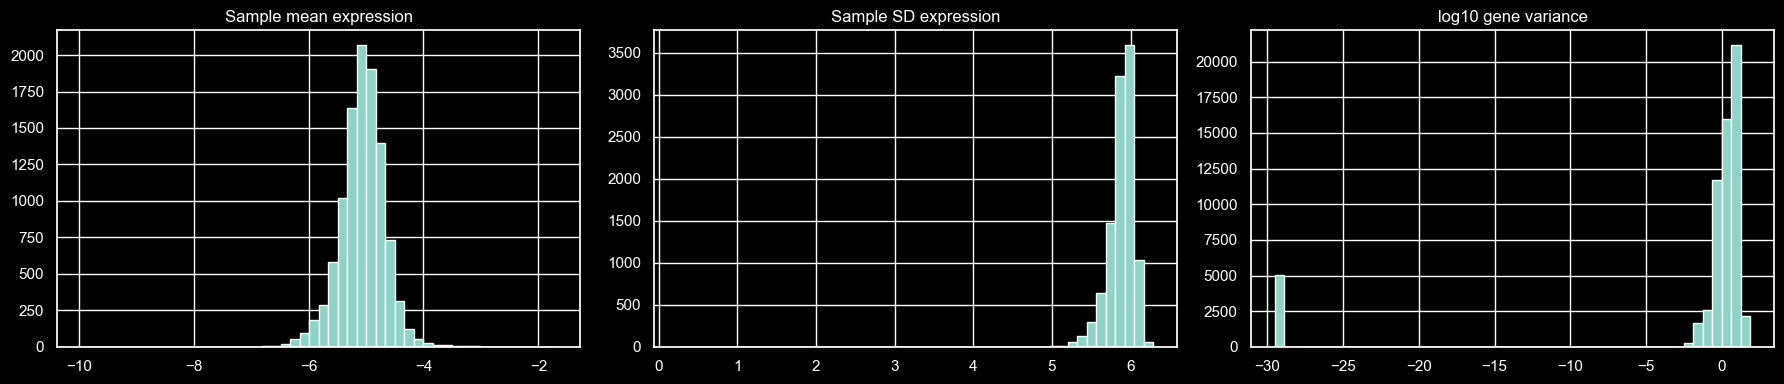

In [11]:
# Distribution checks
sample_means = rna_mat.mean(axis=1)
sample_stds = rna_mat.std(axis=1)
gene_vars = rna_mat.var(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(sample_means, bins=50)
axes[0].set_title("Sample mean expression")

axes[1].hist(sample_stds, bins=50)
axes[1].set_title("Sample SD expression")

axes[2].hist(np.log10(gene_vars.replace(0, np.nan).dropna()), bins=50)
axes[2].set_title("log10 gene variance")
plt.tight_layout()
plt.show()

## TP53 mutation label construction

This is the most important part of EDA.
We want a sample-level TP53 label built from all TP53 mutation rows, not just one selected row.

In [12]:
tp53_rows = mut_raw.loc[mut_raw["gene"].eq("TP53")].copy()

print("TP53 mutation rows:", tp53_rows.shape)
display(tp53_rows.head())

tp53_rows["patient_id"] = tp53_rows[MUT_SAMPLE_COL].map(tcga_patient_id)
tp53_rows["sample_id"] = tp53_rows[MUT_SAMPLE_COL].map(tcga_sample_id)

display(tp53_rows[["sample", "sample_id", "patient_id", "gene", "effect", "Amino_Acid_Change"]].head())

TP53 mutation rows: (3729, 12)


,sample,chr,start,end,reference,alt,gene,effect,Amino_Acid_Change,DNA_VAF,SIFT,PolyPhen
19,TCGA-02-0003-01,17,7577094,7577094,G,A,TP53,Missense_Mutation,p.R282W,0.43,deleterious(0),probably_damaging(0.997)
20,TCGA-02-0003-01,17,7578396,7578396,G,T,TP53,Missense_Mutation,p.H178Q,0.38,deleterious(0),probably_damaging(1)
80,TCGA-02-0033-01,17,7577538,7577538,C,T,TP53,Missense_Mutation,p.R248Q,0.26,deleterious(0),probably_damaging(1)
211,TCGA-02-0055-01,17,7578203,7578203,C,T,TP53,Missense_Mutation,p.V216M,0.61,deleterious(0),probably_damaging(1)
363,TCGA-02-2483-01,17,7577120,7577120,C,T,TP53,Missense_Mutation,p.R273H,0.90,tolerated(0.13),possibly_damaging(0.631)


,sample,sample_id,patient_id,gene,effect,Amino_Acid_Change
19,TCGA-02-0003-01,TCGA-02-0003-01,TCGA-02-0003,TP53,Missense_Mutation,p.R282W
20,TCGA-02-0003-01,TCGA-02-0003-01,TCGA-02-0003,TP53,Missense_Mutation,p.H178Q
80,TCGA-02-0033-01,TCGA-02-0033-01,TCGA-02-0033,TP53,Missense_Mutation,p.R248Q
211,TCGA-02-0055-01,TCGA-02-0055-01,TCGA-02-0055,TP53,Missense_Mutation,p.V216M
363,TCGA-02-2483-01,TCGA-02-2483-01,TCGA-02-2483,TP53,Missense_Mutation,p.R273H


In [13]:
tp53_rows["effect"].value_counts(dropna=False).head(30)

effect
Missense_Mutation         2382
Nonsense_Mutation          488
Frame_Shift_Del            332
Splice_Site                238
Frame_Shift_Ins            101
Silent                      90
In_Frame_Del                68
In_Frame_Ins                11
Intron                       8
3'UTR                        7
5'UTR                        3
Translation_Start_Site       1
Name: count, dtype: int64

In [14]:
PROTEIN_ALTERING_KEYWORDS = {
    "missense", "nonsense", "frameshift", "frame_shift", "splice",
    "nonstop", "translation_start_site", "start_codon", "stop_gained",
    "stop_lost", "inframe", "in_frame"
}

SYNONYMOUS_KEYWORDS = {
    "silent", "synonymous"
}

def classify_tp53_effect(effect):
    if pd.isna(effect):
        return "unknown"
    e = str(effect).strip().lower()

    if any(k in e for k in SYNONYMOUS_KEYWORDS):
        return "synonymous"
    if any(k in e for k in PROTEIN_ALTERING_KEYWORDS):
        # optional finer classes
        if "missense" in e:
            return "missense"
        if "nonsense" in e or "stop_gained" in e or "nonstop" in e:
            return "truncating"
        if "frameshift" in e or "frame_shift" in e:
            return "truncating"
        if "splice" in e:
            return "splice"
        if "inframe" in e or "in_frame" in e:
            return "inframe"
        return "protein_altering"

    return "other_or_unknown"

tp53_rows["tp53_event_class"] = tp53_rows["effect"].map(classify_tp53_effect)
tp53_rows["is_tp53_nonsyn"] = tp53_rows["tp53_event_class"].isin(
    ["missense", "truncating", "splice", "inframe", "protein_altering"]
)
tp53_rows["is_tp53_ambiguous"] = tp53_rows["tp53_event_class"].isin(
    ["other_or_unknown", "unknown"]
)

display(tp53_rows["tp53_event_class"].value_counts(dropna=False))

tp53_event_class
missense            2382
truncating           921
splice               238
synonymous            90
inframe               79
other_or_unknown      18
protein_altering       1
Name: count, dtype: int64

### Important
Later, the main label should usually be:

- `TP53_mut_nonsyn = 1` if a sample has any nonsynonymous / protein-altering TP53 event
- `0` otherwise

But for EDA we should also track ambiguity:
- does the sample have any ambiguous TP53 row?
- does it have multiple TP53 rows?
- does it have mixed TP53 annotations?

In [15]:
tp53_sample = (
    tp53_rows.groupby("sample_id")
    .agg(
        patient_id=("patient_id", "first"),
        n_tp53_rows=("gene", "size"),
        has_any_tp53_row=("gene", lambda x: True),
        has_any_tp53_nonsyn=("is_tp53_nonsyn", "max"),
        has_any_tp53_ambiguous=("is_tp53_ambiguous", "max"),
        n_unique_tp53_effects=("effect", "nunique"),
        n_unique_tp53_event_classes=("tp53_event_class", "nunique"),
        example_effects=("effect", lambda x: "; ".join(pd.Series(x).dropna().astype(str).unique()[:5])),
        example_aa_changes=("Amino_Acid_Change", lambda x: "; ".join(pd.Series(x).dropna().astype(str).unique()[:5])),
    )
    .reset_index()
)

tp53_sample["TP53_mut_nonsyn"] = tp53_sample["has_any_tp53_nonsyn"].astype(int)
tp53_sample["TP53_mut_ambiguous"] = tp53_sample["has_any_tp53_ambiguous"].astype(int)
tp53_sample["has_mixed_tp53_annotation"] = (
    (tp53_sample["has_any_tp53_nonsyn"]) &
    (tp53_sample["has_any_tp53_ambiguous"])
).astype(int)

display(tp53_sample.head())
display(tp53_sample[["TP53_mut_nonsyn", "TP53_mut_ambiguous", "has_mixed_tp53_annotation"]].mean())

,sample_id,patient_id,n_tp53_rows,has_any_tp53_row,has_any_tp53_nonsyn,has_any_tp53_ambiguous,n_unique_tp53_effects,n_unique_tp53_event_classes,example_effects,example_aa_changes,TP53_mut_nonsyn,TP53_mut_ambiguous,has_mixed_tp53_annotation
0,TCGA-02-0003-01,TCGA-02-0003,2,True,True,False,1,1,Missense_Mutation,p.R282W; p.H178Q,1,0,0
1,TCGA-02-0033-01,TCGA-02-0033,1,True,True,False,1,1,Missense_Mutation,p.R248Q,1,0,0
2,TCGA-02-0055-01,TCGA-02-0055,1,True,True,False,1,1,Missense_Mutation,p.V216M,1,0,0
3,TCGA-02-2483-01,TCGA-02-2483,1,True,True,False,1,1,Missense_Mutation,p.R273H,1,0,0
4,TCGA-02-2485-01,TCGA-02-2485,2,True,True,False,1,1,Missense_Mutation,p.R248Q; p.S127Y,1,0,0


TP53_mut_nonsyn              0.983459
TP53_mut_ambiguous           0.005414
has_mixed_tp53_annotation    0.002406
dtype: float64

In [16]:
# Samples with multiple TP53 rows or mixed annotation
display(
    tp53_sample.loc[
        (tp53_sample["n_tp53_rows"] > 1) | (tp53_sample["has_mixed_tp53_annotation"] == 1)
    ].head(20)
)

,sample_id,patient_id,n_tp53_rows,has_any_tp53_row,has_any_tp53_nonsyn,has_any_tp53_ambiguous,n_unique_tp53_effects,n_unique_tp53_event_classes,example_effects,example_aa_changes,TP53_mut_nonsyn,TP53_mut_ambiguous,has_mixed_tp53_annotation
0,TCGA-02-0003-01,TCGA-02-0003,2,True,True,False,1,1,Missense_Mutation,p.R282W; p.H178Q,1,0,0
4,TCGA-02-2485-01,TCGA-02-2485,2,True,True,False,1,1,Missense_Mutation,p.R248Q; p.S127Y,1,0,0
14,TCGA-05-4405-01,TCGA-05-4405,2,True,True,False,1,1,Missense_Mutation,p.C277F; p.R175H,1,0,0
22,TCGA-05-4432-01,TCGA-05-4432,2,True,True,False,2,2,Nonsense_Mutation; Missense_Mutation,p.R342*; p.D281E,1,0,0
24,TCGA-05-5423-01,TCGA-05-5423,2,True,True,False,1,1,Missense_Mutation,p.R249M; p.I195M,1,0,0
31,TCGA-06-0188-01,TCGA-06-0188,2,True,True,False,2,2,Missense_Mutation; Splice_Site,p.A307V; p.X307_splice,1,0,0
34,TCGA-06-0195-01,TCGA-06-0195,2,True,True,False,1,1,Missense_Mutation,p.D281A; p.G266R,1,0,0
46,TCGA-06-2559-01,TCGA-06-2559,2,True,True,False,1,1,Missense_Mutation,p.P190L; p.T155N,1,0,0
48,TCGA-06-2567-01,TCGA-06-2567,2,True,True,False,2,2,Missense_Mutation; Nonsense_Mutation,p.E271K; p.R196*,1,0,0
53,TCGA-06-5417-01,TCGA-06-5417,2,True,True,False,2,2,Missense_Mutation; Nonsense_Mutation,p.I255S; p.R196*,1,0,0


In [17]:
# Find likely phenotype ID and cancer-type columns
pheno_cols_lower = {c.lower(): c for c in pheno_raw.columns}

candidate_type_cols = [c for c in pheno_raw.columns if "cancer type" in c.lower() or "acronym" in c.lower()]
candidate_sample_cols = [c for c in pheno_raw.columns if "sample" in c.lower() or "barcode" in c.lower()]

print("Candidate cancer-type columns:", candidate_type_cols)
print("Candidate sample/barcode columns:", candidate_sample_cols)

Candidate cancer-type columns: ['cancer type abbreviation']
Candidate sample/barcode columns: ['sample']


In [18]:
# TODO: set these after inspection
PHENO_SAMPLE_COL = candidate_sample_cols[0]  # replace explicitly
CANCER_TYPE_COL = [c for c in pheno_raw.columns if c.lower() == "cancer type abbreviation"][0]

pheno = pheno_raw.copy()
pheno["sample_id"] = pheno[PHENO_SAMPLE_COL].map(tcga_sample_id)
pheno["patient_id"] = pheno[PHENO_SAMPLE_COL].map(tcga_patient_id)

display(pheno[[PHENO_SAMPLE_COL, "sample_id", "patient_id", CANCER_TYPE_COL]].head())

,sample,sample_id,patient_id,cancer type abbreviation
0,TCGA-OR-A5J1-01,TCGA-OR-A5J1-01,TCGA-OR-A5J1,ACC
1,TCGA-OR-A5J2-01,TCGA-OR-A5J2-01,TCGA-OR-A5J2,ACC
2,TCGA-OR-A5J3-01,TCGA-OR-A5J3-01,TCGA-OR-A5J3,ACC
3,TCGA-OR-A5J4-01,TCGA-OR-A5J4-01,TCGA-OR-A5J4,ACC
4,TCGA-OR-A5J5-01,TCGA-OR-A5J5-01,TCGA-OR-A5J5,ACC


In [19]:
# Search for sample-type / tumour-normal / purity-like columns
candidate_sampletype_cols = [c for c in pheno.columns if "sample type" in c.lower() or "tumor" in c.lower() or "normal" in c.lower()]
candidate_purity_cols = [c for c in pheno.columns if "purity" in c.lower()]

print("Candidate sample-type columns:", candidate_sampletype_cols)
print("Candidate purity columns:", candidate_purity_cols)

Candidate sample-type columns: ['ajcc_pathologic_tumor_stage', 'tumor_status', 'new_tumor_event_type', 'new_tumor_event_site', 'new_tumor_event_site_other', 'new_tumor_event_dx_days_to', 'residual_tumor']
Candidate purity columns: []


In [20]:
rna_df = rna_mat.copy().reset_index()
rna_df.rename(columns={"sample_id": "sample_id"}, inplace=True)

merged = (
    rna_df
    .merge(tp53_sample, on="sample_id", how="left")
    .merge(pheno, on="sample_id", how="left", suffixes=("", "_pheno"))
)

print("Merged shape:", merged.shape)
display(merged.head())

Merged shape: (10535, 60546)


,sample_id,ENSG00000242268.2,ENSG00000259041.1,ENSG00000270112.3,ENSG00000167578.16,ENSG00000278814.1,ENSG00000078237.5,ENSG00000269416.5,ENSG00000263642.1,ENSG00000146083.11,ENSG00000158486.13,ENSG00000273639.4,ENSG00000198242.13,ENSG00000231981.3,ENSG00000269475.2,ENSG00000134108.12,ENSG00000261030.1,ENSG00000172137.18,ENSG00000276644.4,ENSG00000240423.1,ENSG00000271616.1,ENSG00000234881.1,ENSG00000236040.1,ENSG00000231105.1,ENSG00000094963.13,ENSG00000182141.9,ENSG00000280143.1,ENSG00000251334.2,ENSG00000231112.1,ENSG00000258610.1,ENSG00000264981.1,ENSG00000275265.1,ENSG00000185105.4,ENSG00000233540.1,ENSG00000102174.8,ENSG00000166391.14,ENSG00000232001.1,ENSG00000270469.1,ENSG00000225275.4,ENSG00000234253.1,ENSG00000070087.13,ENSG00000262950.1,ENSG00000255420.1,ENSG00000280038.1,ENSG00000153561.12,ENSG00000251538.5,ENSG00000269148.1,ENSG00000253438.2,ENSG00000235411.1,ENSG00000179262.9,ENSG00000278099.1,ENSG00000104833.10,ENSG00000166368.2,ENSG00000206072.12,ENSG00000006695.10,ENSG00000258630.1,ENSG00000187513.8,ENSG00000225269.2,ENSG00000214062.5,ENSG00000095587.8,ENSG00000167700.8,ENSG00000274219.1,ENSG00000254102.1,ENSG00000265096.1,ENSG00000064601.16,ENSG00000227766.1,ENSG00000008517.16,ENSG00000264085.1,ENSG00000261475.2,ENSG00000229637.3,ENSG00000266644.1,ENSG00000227896.2,ENSG00000214541.3,ENSG00000070081.15,ENSG00000166634.6,ENSG00000275479.1,ENSG00000112309.10,ENSG00000199812.1,ENSG00000261789.1,ENSG00000254092.1,ENSG00000158480.10,ENSG00000197421.9,ENSG00000280171.1,ENSG00000260900.1,ENSG00000266579.1,ENSG00000278732.1,ENSG00000196167.9,ENSG00000264438.2,ENSG00000200288.1,ENSG00000207000.1,ENSG00000254131.1,ENSG00000118972.1,ENSG00000264104.1,ENSG00000179833.4,ENSG00000165312.6,ENSG00000159618.15,ENSG00000064225.12,ENSG00000221372.1,ENSG00000250571.6,ENSG00000057294.13,...,ENSG00000206792.1,ENSG00000170522.9,ENSG00000241667.1,ENSG00000279507.1,ENSG00000162999.12,ENSG00000099991.16,ENSG00000212518.1,ENSG00000102265.11,ENSG00000133313.14,ENSG00000231700.3,ENSG00000214216.10,ENSG00000263414.1,ENSG00000265064.1,ENSG00000279778.1,ENSG00000223671.2,ENSG00000263573.1,ENSG00000222213.1,ENSG00000214124.3,ENSG00000206836.1,ENSG00000233845.1,ENSG00000066044.13,ENSG00000264491.1,ENSG00000146587.17,ENSG00000278151.1,ENSG00000228658.1,ENSG00000173930.8,ENSG00000274396.1,ENSG00000107863.16,ENSG00000199892.2,ENSG00000221760.1,ENSG00000253333.1,ENSG00000213782.7,ENSG00000146707.14,ENSG00000212084.2,ENSG00000248838.2,ENSG00000255083.1,ENSG00000158417.10,ENSG00000223665.1,ENSG00000203729.8,ENSG00000238300.1,ENSG00000221756.1,ENSG00000089177.17,ENSG00000186115.12,ENSG00000009694.13,ENSG00000238244.3,ENSG00000216352.1,ENSG00000123685.8,ENSG00000267117.1,ENSG00000273233.1,ENSG00000105063.18,ENSG00000231119.2,ENSG00000280861.1,ENSG00000181518.3,patient_id,n_tp53_rows,has_any_tp53_row,has_any_tp53_nonsyn,has_any_tp53_ambiguous,n_unique_tp53_effects,n_unique_tp53_event_classes,example_effects,example_aa_changes,TP53_mut_nonsyn,TP53_mut_ambiguous,has_mixed_tp53_annotation,sample,_PATIENT,cancer type abbreviation,age_at_initial_pathologic_diagnosis,gender,race,ajcc_pathologic_tumor_stage,clinical_stage,histological_type,histological_grade,initial_pathologic_dx_year,menopause_status,birth_days_to,vital_status,tumor_status,last_contact_days_to,death_days_to,cause_of_death,new_tumor_event_type,new_tumor_event_site,new_tumor_event_site_other,new_tumor_event_dx_days_to,treatment_outcome_first_course,margin_status,residual_tumor,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,Redaction,patient_id_pheno
0,TCGA-19-1787-01,-9.9658,-9.9658,-3.8160,5.2998,-9.9658,3.5086,0.8647,-9.9658,4.2465,-5.0116,-9.9658,10.1571,-9.9658,-9.9658,5.5775,-9.9658,7.8896,-2.0529,-3.8160,-9.9658,-4.0350,-9.9658,-1.8314,1.5266,1.8918,1.1577,-9.9658,-9.9658,3.7614,-9.9658,-3.4580,-3.4580,-9.9658,2.1894,-5.5735,-9.9658,-9.9658,-9.9658,-4.2934,7.7651,-9.9658,-5.5735,-3.8160,4.5790,-9.9658,-1.4699,-3.3076,-2.3147,6.7856,-9.9658,6.6672,-9.9658,-9.9658,2.5112,-9.9658,2.7826,

In [21]:
# Mutation-negative samples should be explicit zeros
merged["TP53_mut_nonsyn"] = merged["TP53_mut_nonsyn"].fillna(0).astype(int)
merged["TP53_mut_ambiguous"] = merged["TP53_mut_ambiguous"].fillna(0).astype(int)
merged["has_any_tp53_row"] = merged["has_any_tp53_row"].fillna(False).astype(bool)
merged["has_mixed_tp53_annotation"] = merged["has_mixed_tp53_annotation"].fillna(0).astype(int)

display(
    merged[["TP53_mut_nonsyn", "TP53_mut_ambiguous", "has_any_tp53_row", "has_mixed_tp53_annotation"]]
    .mean()
)

TP53_mut_nonsyn              0.287897
TP53_mut_ambiguous           0.001614
has_any_tp53_row             0.292359
has_mixed_tp53_annotation    0.000759
dtype: float64

## Cohort definition audit

Before finalizing the EDA cohort, check:
- duplicate sample IDs
- duplicate patient IDs
- missing cancer type
- possible normal samples
- multiple samples per patient

In [22]:
print("Unique sample IDs:", merged["sample_id"].nunique())
print("Rows:", len(merged))
print("Unique patient IDs:", merged["patient_id"].nunique())
print("Duplicated sample IDs:", merged["sample_id"].duplicated().sum())
print("Patients with >1 sample:", (merged["patient_id"].value_counts() > 1).sum())

display(merged[CANCER_TYPE_COL].value_counts(dropna=False).head(40))

Unique sample IDs: 10535
Rows: 10535
Unique patient IDs: 3080
Duplicated sample IDs: 0
Patients with >1 sample: 0


cancer type abbreviation
BRCA    1211
KIRC     603
LUAD     574
THCA     571
HNSC     564
PRAD     548
LUSC     548
LGG      522
SKCM     470
STAD     450
OV       427
BLCA     426
LIHC     421
COAD     329
KIRP     321
CESC     309
SARC     264
ESCA     195
UCEC     194
PCPG     185
PAAD     183
LAML     173
GBM      165
TGCT     137
THYM     121
READ     102
KICH      91
MESO      87
UVM       79
ACC       77
UCS       57
DLBC      47
CHOL      45
NaN       39
Name: count, dtype: int64

In [23]:
# If you find a tumour/normal sample-type column, inspect it here
# display(merged[SAMPLE_TYPE_COL].value_counts(dropna=False))

### Decision to record
Fill in this section after inspection:

- Keep only tumour samples? [Yes/No]
- Keep only one sample per patient? [Yes/No]
- If yes, what rule? [e.g. first tumour sample, primary tumour only]
- Exclude samples with missing cancer type? [Yes/No]

In [24]:
label_summary = pd.Series({
    "n_samples": len(merged),
    "n_tp53_nonsyn": merged["TP53_mut_nonsyn"].sum(),
    "tp53_nonsyn_rate": merged["TP53_mut_nonsyn"].mean(),
    "n_tp53_ambiguous": merged["TP53_mut_ambiguous"].sum(),
    "ambiguous_rate": merged["TP53_mut_ambiguous"].mean(),
    "n_mixed_tp53_annotation": merged["has_mixed_tp53_annotation"].sum(),
})
display(label_summary.to_frame("value"))

,value
n_samples,10535.000000
n_tp53_nonsyn,3033.000000
tp53_nonsyn_rate,0.287897
n_tp53_ambiguous,17.000000
ambiguous_rate,0.001614
n_mixed_tp53_annotation,8.000000


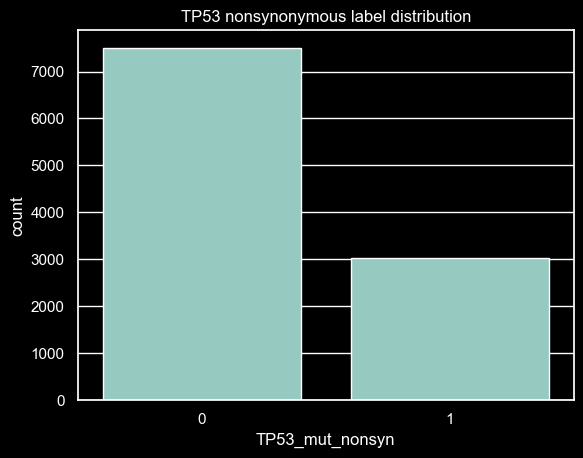

In [25]:
sns.countplot(data=merged, x="TP53_mut_nonsyn")
plt.title("TP53 nonsynonymous label distribution")
plt.show()

In [26]:
cancer_stats = (
    merged.groupby(CANCER_TYPE_COL)
    .agg(
        n_samples=("sample_id", "size"),
        tp53_rate=("TP53_mut_nonsyn", "mean"),
        n_tp53=("TP53_mut_nonsyn", "sum"),
    )
    .sort_values("n_samples", ascending=False)
)

display(cancer_stats.head(40))

,n_samples,tp53_rate,n_tp53
cancer type abbreviation,,,
BRCA,1211,0.215524,261
KIRC,603,0.018242,11
LUAD,574,0.447735,257
THCA,571,0.005254,3
HNSC,564,0.622340,351
PRAD,548,0.105839,58
LUSC,548,0.722628,396
LGG,522,0.461686,241
SKCM,470,0.148936,70


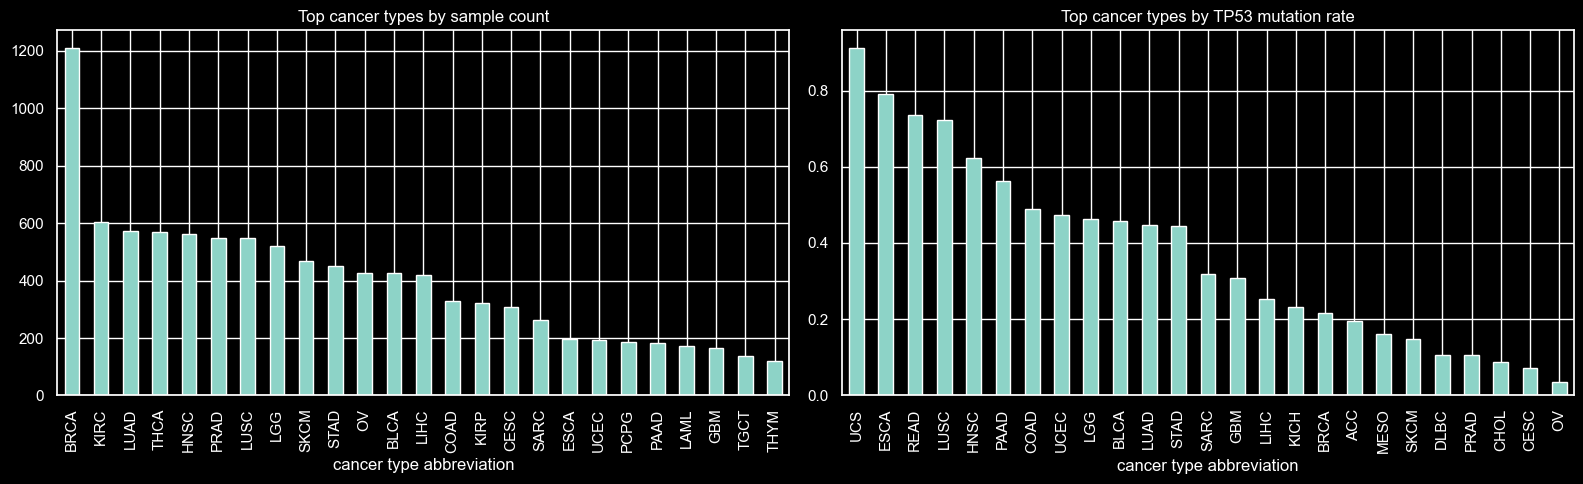

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cancer_stats["n_samples"].sort_values(ascending=False).head(25).plot(kind="bar", ax=axes[0])
axes[0].set_title("Top cancer types by sample count")

cancer_stats["tp53_rate"].sort_values(ascending=False).head(25).plot(kind="bar", ax=axes[1])
axes[1].set_title("Top cancer types by TP53 mutation rate")

plt.tight_layout()
plt.show()

### What to comment on
- Are TP53 mutation rates highly uneven across cancer types?
- Are there very small cancer-type groups?
- Would a pan-cancer random split risk learning cancer type rather than TP53 biology?

In [28]:
metadata_cols_to_check = [CANCER_TYPE_COL, "patient_id", "sample_id"]
metadata_missing = merged[metadata_cols_to_check].isna().mean().sort_values(ascending=False)
display(metadata_missing.to_frame("missing_fraction"))

,missing_fraction
patient_id,0.707641
cancer type abbreviation,0.003702
sample_id,0.000000


In [29]:
# If you identify purity / age / sex / stage columns
candidate_covariates = [c for c in merged.columns if any(k in c.lower() for k in ["purity", "age", "sex", "stage"])]
candidate_covariates[:30]

['age_at_initial_pathologic_diagnosis',
 'ajcc_pathologic_tumor_stage',
 'clinical_stage']

RNA feature count: 60498


count    6.049800e+04
mean     4.703386e+00
std      5.730210e+00
min      3.155743e-30
25%      5.719971e-01
50%      2.287361e+00
75%      7.361204e+00
max      7.417138e+01
dtype: float64

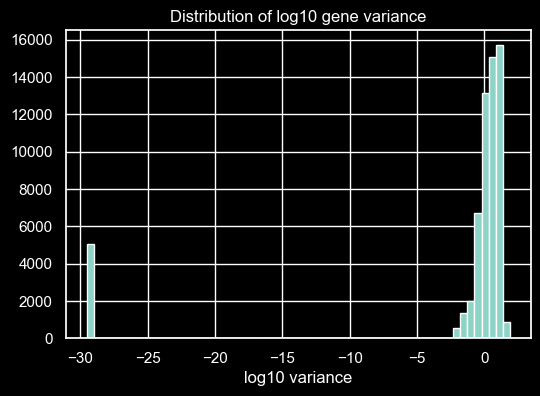

In [30]:
gene_cols = [c for c in merged.columns if c in rna_mat.columns]

expr = merged[gene_cols]

print("RNA feature count:", expr.shape[1])

gene_var = expr.var(axis=0)
display(gene_var.describe())

plt.figure(figsize=(6, 4))
plt.hist(np.log10(gene_var.replace(0, np.nan).dropna()), bins=60)
plt.title("Distribution of log10 gene variance")
plt.xlabel("log10 variance")
plt.show()

In [31]:
# Fraction of near-constant genes at a simple threshold
var_thresholds = [1e-6, 1e-4, 1e-3, 1e-2]
for t in var_thresholds:
    frac = (gene_var <= t).mean()
    print(f"Fraction genes with variance <= {t}: {frac:.3f}")

Fraction genes with variance <= 1e-06: 0.084
Fraction genes with variance <= 0.0001: 0.084
Fraction genes with variance <= 0.001: 0.084
Fraction genes with variance <= 0.01: 0.085


### EDA conclusion to record
This section should only motivate possible train-only filtering later.
Do not select final genes here.

In [32]:
# Use top variable genes for stable PCA
top_var_genes = gene_var.sort_values(ascending=False).head(TOP_VAR_GENES_FOR_PCA).index.tolist()

X_pca_input = merged[top_var_genes].copy()
X_pca_input = X_pca_input.fillna(X_pca_input.median())

X_scaled = StandardScaler().fit_transform(X_pca_input)
pca = PCA(n_components=10, random_state=RANDOM_STATE)
pcs = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": pcs[:, 0],
    "PC2": pcs[:, 1],
    "TP53_mut_nonsyn": merged["TP53_mut_nonsyn"].values,
    CANCER_TYPE_COL: merged[CANCER_TYPE_COL].values,
})
display(pca_df.head())
print("Explained variance ratio:", pca.explained_variance_ratio_[:5])

,PC1,PC2,TP53_mut_nonsyn,cancer type abbreviation
0,-24.388091,-8.330318,1,GBM
1,-36.959201,-13.042735,0,LGG
2,-8.084918,30.331599,0,LIHC
3,14.136807,-20.792216,0,CESC
4,13.651394,4.632379,1,LUAD


Explained variance ratio: [0.10981752 0.0580142  0.04350079 0.039535   0.0328155 ]


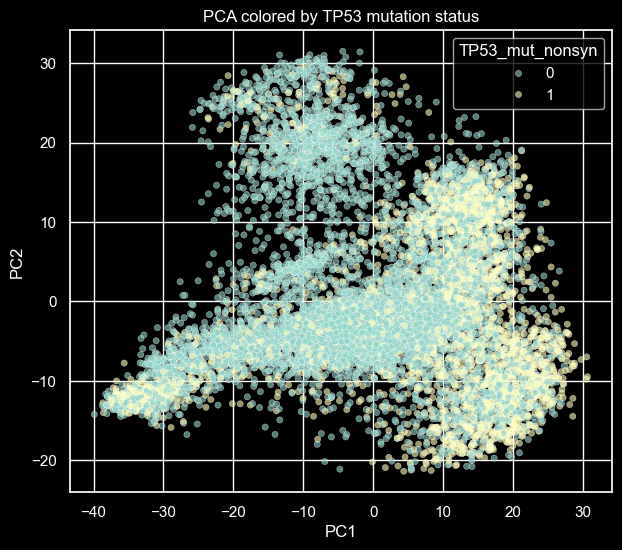

In [33]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="TP53_mut_nonsyn", alpha=0.6, s=20)
plt.title("PCA colored by TP53 mutation status")
plt.show()

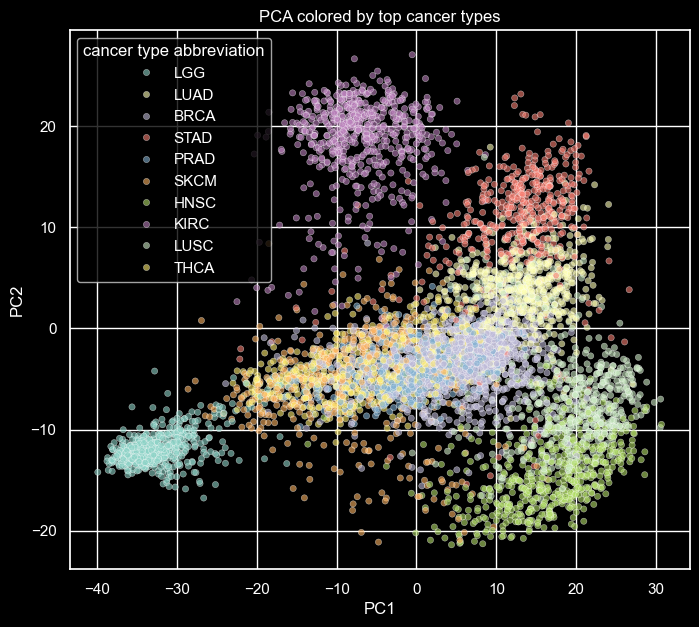

In [34]:
# Show only top cancer types to keep plot readable
top_types = cancer_stats.head(10).index
plot_df = pca_df[pca_df[CANCER_TYPE_COL].isin(top_types)].copy()

plt.figure(figsize=(8, 7))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue=CANCER_TYPE_COL, alpha=0.6, s=20)
plt.title("PCA colored by top cancer types")
plt.show()

### Key question
Does PCA separate more strongly by cancer type than by TP53 status?
If yes, that is evidence that cancer-type-aware evaluation will be necessary in modeling.

In [35]:
# Optional if file is available
if TP53_TARGETS_PATH.exists():
    tp53_targets = pd.read_csv(TP53_TARGETS_PATH)
    display(tp53_targets.head())
    print("Target list shape:", tp53_targets.shape)

,gene_symbol
0,ABCA12
1,ABHD4
2,ABTB2
3,ACER2
4,ACTA2


Target list shape: (343, 1)


In [36]:
# Simple exploratory inspection of a few canonical TP53 genes
genes_of_interest = ["TP53", "MDM2", "CDKN1A", "BAX", "DDB2", "XPC", "FDXR", "RPS27L", "DRAM1", "EDA2R"]
genes_present = [g for g in genes_of_interest if g in gene_cols]
print("Genes present:", genes_present)

if genes_present:
    mean_by_label = (
        merged.groupby("TP53_mut_nonsyn")[genes_present]
        .mean()
        .T
        .rename(columns={0: "TP53_WT", 1: "TP53_MUT"})
    )
    display(mean_by_label)

Genes present: []


In [37]:
# Quick effect-size style ranking, purely exploratory
group0 = merged.loc[merged["TP53_mut_nonsyn"] == 0, gene_cols]
group1 = merged.loc[merged["TP53_mut_nonsyn"] == 1, gene_cols]

effect_size = group1.mean(axis=0) - group0.mean(axis=0)
effect_df = effect_size.sort_values(ascending=False).rename("mean_diff").to_frame()

display(effect_df.head(20))
display(effect_df.tail(20))

,mean_diff
ENSG00000169469.8,4.628678
ENSG00000241794.1,4.286529
ENSG00000205420.10,4.284580
ENSG00000169474.4,4.221714
ENSG00000105388.14,4.180111
ENSG00000163216.6,4.160418
ENSG00000185479.5,4.118624
ENSG00000143556.8,3.870909
ENSG00000206075.13,3.822887
ENSG00000163209.14,3.807745


,mean_diff
ENSG00000198889.4,-1.929636
ENSG00000075891.21,-1.949672
ENSG00000238243.3,-1.953000
ENSG00000249494.5,-1.966845
ENSG00000131080.14,-1.986145
ENSG00000183747.11,-2.046291
ENSG00000066813.14,-2.054592
ENSG00000277081.1,-2.060764
ENSG00000149124.10,-2.064449
ENSG00000124564.17,-2.065682


### Warning
These exploratory RNA-label associations should not be used as final feature selection.
Any supervised selection must happen inside the modeling pipeline after splitting.

In [38]:
# Not full modeling yet — just descriptive prevalence by cancer type
display(
    merged.groupby(CANCER_TYPE_COL)["TP53_mut_nonsyn"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

cancer type abbreviation
UCS     0.912281
ESCA    0.789744
READ    0.735294
LUSC    0.722628
HNSC    0.622340
PAAD    0.562842
COAD    0.489362
UCEC    0.474227
LGG     0.461686
BLCA    0.457746
LUAD    0.447735
STAD    0.444444
SARC    0.318182
GBM     0.309091
LIHC    0.254157
KICH    0.230769
BRCA    0.215524
ACC     0.194805
MESO    0.160920
SKCM    0.148936
Name: TP53_mut_nonsyn, dtype: float64

If cancer type alone already strongly stratifies TP53 prevalence, the modeling notebook should include:
- a metadata-only baseline
- an RNA-only model
- a cancer-type-aware validation strategy

# EDA conclusions

## Proposed main label
- Primary target: `TP53_mut_nonsyn`

## Cohort definition
- [Fill after inspection]
- Tumour-only? [Yes/No]
- One sample per patient? [Yes/No]
- Pan-cancer or one cancer type? [Fill]

## Main findings
- TP53 class balance: [fill]
- Cancer-type imbalance: [fill]
- Ambiguous/mixed TP53 annotations: [fill]
- RNA QC issues: [fill]
- Missingness issues: [fill]

## Main modeling risks
- Cancer-type confounding
- Patient/sample duplication leakage
- Ambiguous TP53 annotation
- Supervised feature selection leakage if done before split

## Modeling notebook plan
- Dummy baseline
- Metadata-only baseline
- RNA-only regularized logistic regression
- Possibly RNA + metadata
- Grouped cancer-type evaluation if pan-cancer